# 3-lens System using MeepSAT

In this Tutorial, we are going to simulate a complex 3 lens system with all the possible components currently availabe in MeepSATs functionality. We will be simulating the system in low-frequency (LF) range (90, 120, 150 GHz).

We will be using no AR Coatings in these simulations since it requires a minimum of resolution 19 pixels per mm (which isn't feasible to run in your local device). But later, we will give a tutorial on how to do that on a HPC facility. 

`Note`: For now we will use 3 pixels per mm for demonstration purpose only (DO NOT TRUST THE RESULTS WITH THIS RESOLUTION since the minimum requirement now is 6 pixels per mm). You can later change this resolution and run it to get accurate field informations.

The general workflow is the same that we have shown in the previous examples (https://github.com/aa16oaslak/MeepSAT/blob/main/examples/01_simple_single_lens_ARC.ipynb)

In [1]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json
import math

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

# JSON file path representing mainly the different optical components parameters
json_file_path = 'auxilary_data/04_3lens_system_noARC/3lens_system_noARC.json'
data = mpsat_helpers.read_json(json_file_path)

# Some universal constants
c_mm_s = 299792458.0 * 1000.0  # Speed of light in mm/s (m/s -> mm/s)
# Frequency of the simulation
freq = 150.0  # Frequency in GHz
a = 1  # 1 meep unit = 1 mm  
wvl = c_mm_s / (freq * 1e9)  # Wavelength in mm
freq_meep = 1.0 / (wvl * a)
print("freq (meep units):", freq_meep)

# Edit the freq in the JSON file 
data["sources"]["source1"]["frequecy"] = freq_meep

# Savepath: For storing the output generated during the simulation
savepath = f'auxilary_data/04_3lens_system_noARC/TRV/output_files/{freq}GHz'
os.makedirs(savepath, exist_ok=True)
data["output"]["savepath"]["path"] = savepath

# Initialising MEEPSAT Simulation
cell_X, cell_Y, cell_Z = data["simulation"]['primary_params']['cell_size']['x'], data["simulation"]['primary_params']['cell_size']['y'], data["simulation"]['primary_params']['cell_size']['z'] # Cell Size without considering the PML thickness and its factor


# Initialize the simulation with the different parameters
mpsat_sim = sim.sim_init(sim_name= str(data["simulation"]["name"]),
                        cell_size= [cell_X, cell_Y, cell_Z], # [sx, sy, sz] in mm
                        smallest_freq= data["simulation"]['primary_params']['smallest_freq'], 
                        resolution= data["simulation"]['primary_params']['resolution'],
                        boundary_layer_type= data['boundary_layers']['boundary']['type'],
                        boundary_layer_size= data['boundary_layers']['boundary']['size'],
                        factor_dpml= data['boundary_layers']['boundary']['factor_dpml'])

# Checking resolution and PML thickness 
# This function will automatically check all the length scales and wavelength scales
# data, mpsat_sim = sim.check_resolution_and_pml(
#     data=data, 
#     mpsat_sim=mpsat_sim,
#     smallest_freq=data["simulation"]['primary_params']['smallest_freq'],
#     highest_n=data["lenses"]["lens1"]["n_refr"]
# )

# Print the simulation parameters
print("\nMEEPSAT SIMULATION PARAMETERS:")
mpsat_sim.print_simulation_parameters()


# Boundary Layers
x_left_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.Low)
x_right_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.High)
y_down_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.Low)
y_up_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.High)

custom_boundary_layers = [x_left_boundary, x_right_boundary, y_down_boundary, y_up_boundary]

# Creating the epsilon map for the simulation cell
size_x, size_y, size_z = mpsat_sim.cell_size[0], mpsat_sim.cell_size[1], mpsat_sim.cell_size[2]
res = int(mpsat_sim.resolution)  # Ensure resolution is an integer
# Create the epsilon map: total size of the simulation cell in all the axis multiplied by the resolution + 1
epsilon_map = np.ones((int((size_x)*res+1), 
                       int((size_y)*res+1)), dtype = float)


Using MPI version 4.1, 1 processes
freq (meep units): 0.5003461427972281

MEEPSAT SIMULATION PARAMETERS:
Simulation name: 3lens_system_noARC
Cell size: [1630, 834, 0]
Frequency: 0.25
Wavelength: 4.0
Resolution: 3
Boundary layer type: PML
Boundary layer size: 2
Factor for PML boundary layer thickness: 2


Let's add the absorbers on the side walls stretching from the PML layer to the y=+-200 mm mark. We will follow the same absorber design as we have been following from the previous tutorials and use `Pyramidal` edge taper.

The start and end point of the absorbers were calculated by using the following schematic:

![3-lens system schematic](auxilary_data/04_3lens_system_noARC/schematic_3lens.jpg)

In [2]:
#~ Absorbers at the bottom of the wall
absorbers_down = comp_meep.Absorbers(
    # Absorber Dimensions:
    p=6,
    p_h_ratio=1.5,
    taper_type='Pyramidal',
    grid_size_sx=size_x,
    grid_size_sy=size_y,
    resolution=res,
    eps_array=epsilon_map,
    geometry_objects=[],
    # Impedance Parameters:
    z0=1,
    z1=1/math.sqrt(5.4),
    # Centre, Angle and orientation Parameters; 
    # They don't work if start and end points are given
    center_x_mm=0,
    center_y_mm=0,
    orientation="+y",
    angle_axis="x",
    # Substrate parameters
    substrate_thickness=[5, 
                         212],
    substrate_material=[None, # means use the absorber material as substrate
                        mp.perfect_electric_conductor],
    add_substrate = True,
    # Absorber Material parameters
    epsilon_r=5.4,
    epsilon_i=0.8,
    # material=None,
    material_type = 'narrow_bandwidth_absorption',
    freq=data["sources"]['source1']["frequecy"],
    # Placing absorbers between two points in a straight line
    start_point= (11, -200),
    end_point= (813, -200),
    overall_factor = 1,
    plot_alpha=False,
    plot_profile=False,
    savepath=savepath,
    plot_mesh = False
)


# absorbers at the top of the wall
absorbers_up = comp_meep.Absorbers(
    # Absorber Dimensions:
    p=6,
    p_h_ratio=1.5,
    taper_type='Pyramidal',
    grid_size_sx=size_x,
    grid_size_sy=size_y,
    resolution=res,
    eps_array=epsilon_map,
    geometry_objects=[],
    # Impedance Parameters:
    z0=1,
    z1=1/math.sqrt(5.4),
    # Centre, Angle and orientation Parameters; 
    # They don't work if start and end points are given
    center_x_mm=0,
    center_y_mm=0,
    orientation="-y",
    angle_axis="x",
    # Substrate parameters
    substrate_thickness=[5, 
                         212],
    substrate_material=[None, # means use the absorber material as substrate
                        mp.perfect_electric_conductor],
    add_substrate = True,
    # Absorber Material parameters
    epsilon_r=5.4,
    epsilon_i=0.8,
    # material=None,
    material_type = 'narrow_bandwidth_absorption',
    freq=data["sources"]['source1']["frequecy"],
    # Placing absorbers between two points in a straight line
    start_point= (11, 200),
    end_point= (813, 200),
    overall_factor = 1,
    plot_alpha=False,
    plot_profile=False,
    savepath=savepath,
    plot_mesh = False
)

mpsat_sim.meep_geometry.extend(absorbers_up.assemble())
mpsat_sim.meep_geometry.extend(absorbers_down.assemble())



Creating narrow bandwidth absorption material using the following instructions: https://meep.readthedocs.io/en/latest/Materials/#conductivity-and-complex
Creating narrow bandwidth absorption material using the following instructions: https://meep.readthedocs.io/en/latest/Materials/#conductivity-and-complex
Placing absorbers between points: (11, 200) and (813, 200)
Line angle: 0.00°
Calculated perpendicular: 90.00°
Active Absorber orientation: -y
Direction: [1. 0.]
Perpendicular: [-0.  1.]
Calculated 133 absorber centers with spacing: 5.98mm
Absorber centers: [array([ 16.9924812, 200.       ]), array([ 22.97744361, 200.        ]), array([ 28.96240602, 200.        ]), array([ 34.94736842, 200.        ]), array([ 40.93233083, 200.        ]), array([ 46.91729323, 200.        ]), array([ 52.90225564, 200.        ]), array([ 58.88721805, 200.        ]), array([ 64.87218045, 200.        ]), array([ 70.85714286, 200.        ]), array([ 76.84210526, 200.        ]), array([ 82.82706767, 200.    

Now let's define the forebaffles form the start points of the absorbers!

In [3]:
# Define the forebaffle geometry parameters 
forebaffle_height = 204.66019330591573 # mm
forebaffle_base = 669.4133291741248 # mm
forebaffle_hypotenuse = np.sqrt(forebaffle_height**2 + forebaffle_base**2) # mm
forebaffle_angle = np.degrees(np.arctan(forebaffle_height / forebaffle_base)) # degrees
forebaffle_thickness = 6
forebaffle_absorber_thick = 3
forebaffle_num_periods = 1
forebaffle_amplitude = 0

# Bottom Forebaffle
x_start_bottom, y_start_bottom = 11, -200

fb_bottom = comp_meep.Forebaffle(
    mpsat_sim= mpsat_sim,
    epsilon_map= epsilon_map,
    angle_degrees=180+forebaffle_angle, #180-forebaffle_angle,
    x_vertex= x_start_bottom,
    y_vertex= y_start_bottom,
    hypotenuse= forebaffle_hypotenuse,
    material=mp.perfect_electric_conductor,  # ← Use this instead
    name="Bottom Forebaffle",
    shape='spline',
    num_periods=forebaffle_num_periods,
    amplitude=forebaffle_amplitude,
    no_of_points=500,
    scaling_factor=3,
    spline_degree=3,
    spline_smoothing=1,
    fb_thickness=forebaffle_thickness,
    add_absorber=True,
    absorber_side= 'above',
    absorber_epsilon_real=5.4,
    absorber_epsilon_imag=0.7,
    absorber_thickness=forebaffle_absorber_thick
)

fb_bottom_assembled = fb_bottom.assemble()
mpsat_sim.meep_geometry.extend(fb_bottom_assembled)

# Top Forebaffle
x_start_top, y_start_top = 11, 200

fb_top = comp_meep.Forebaffle(
    mpsat_sim= mpsat_sim,
    epsilon_map= epsilon_map,
    angle_degrees=180-forebaffle_angle, #180-forebaffle_angle,
    x_vertex= x_start_top,
    y_vertex= y_start_top,
    hypotenuse= forebaffle_hypotenuse,
    material=mp.perfect_electric_conductor,  # ← Use this instead
    name="Top Forebaffle",
    shape='spline',
    num_periods=forebaffle_num_periods,
    amplitude=forebaffle_amplitude,
    no_of_points=500,
    scaling_factor=3,
    spline_degree=3,
    spline_smoothing=1,
    fb_thickness=forebaffle_thickness,
    add_absorber=True,
    absorber_side= 'below',
    absorber_epsilon_real=5.4,
    absorber_epsilon_imag=0.7,
    absorber_thickness=forebaffle_absorber_thick
)

fb_top_assembled = fb_top.assemble()
mpsat_sim.meep_geometry.extend(fb_top_assembled)


base 669.4133291741247 	 height 204.6601933059157
Calculated vertices: v1=Vector3<11.0, -200.0, 0.0>, v2=Vector3<-658.4133291741247, -200.0, 0.0>, v3=Vector3<-658.4133291741247, -404.6601933059157, 0.0>
Quadrant: 3
base 669.4133291741248 	 height 204.66019330591558
Calculated vertices: v1=Vector3<11.0, 200.0, 0.0>, v2=Vector3<-658.4133291741248, 200.0, 0.0>, v3=Vector3<-658.4133291741248, 404.6601933059156, 0.0>
Quadrant: 2


Now let's add the sources, lenses and aperture component

In [4]:
# Adding Source
source_list = []
exec(json_to_script.source_script(data))

# Adding lens (if given)
exec(json_to_script.add_lens(data))

# Adding box slabs (if given)
exec(json_to_script.add_slab(data))

# Adding aperture (if given)
exec(json_to_script.add_aperture(data))

Angle of the source:3.141592653589793 rad = 180 degrees
Additional arguments for the ContinuousSource:  {'start_time': 0, 'end_time': 1e+20}
Additional arguments for GaussianBeamSource:  {'beam_x0': Vector3<0.0, 0.0, 0.0>, 'beam_E0': Vector3<0.0, 0.0, 1.0>}
Gaussian beam source assembled!
Saving epsilon map to HDF5 file...
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!


Now let's plot the epsilon map and visualise the results

-----------
Initializing structure...
read in 4891x2503x1 epsilon-input-file "auxilary_data/04_3lens_system_noARC/TRV/output_files/150.0GHz3lens_system_noARC_epsilon_map.h5"
Halving computational cell along direction y
time for choose_chunkdivision = 0.359438 s
read in 4891x2503x1 epsilon-input-file "auxilary_data/04_3lens_system_noARC/TRV/output_files/150.0GHz3lens_system_noARC_epsilon_map.h5"
Working in 2D dimensions.
Computational cell is 1630 x 834 x 0 with resolution 3
     block, center = (16.6667,202.5,0)
          size (6,5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.4,5.4,5.4)
     block, center = (16.6667,311,0)
          size (6,212,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (17.1111,192.556,0.5)
          height 1, axis (0,0,1), sidewall angle: 0 radians, 3 vertices:
          (16.6667,191.333,0)
          (17.6667,194,0)
        

FloatProgress(value=0.0, description='0% done ', max=0.0)

run 0 finished at t = 0.0 (0 timesteps)


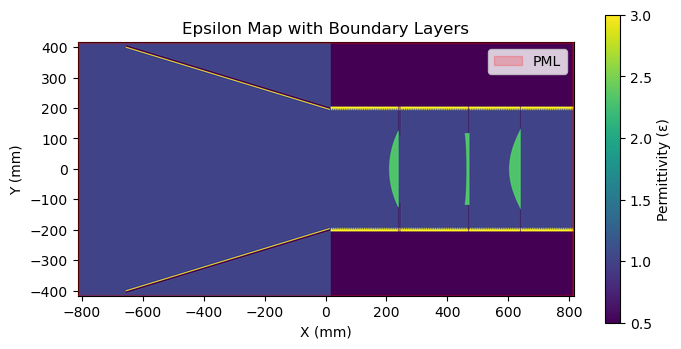

Epsilon plot saved to: auxilary_data/04_3lens_system_noARC/TRV/output_files/150.0GHz/geometry_plot.png
Epsilon data saved to: auxilary_data/04_3lens_system_noARC/TRV/output_files/150.0GHz/geometry_plot.h5


In [5]:
# DEFINING THE SIMULATION OBJECT
# Mirror symmetry along y direction (x=0 plane)
symmetries = [mp.Mirror(mp.Y, phase=+1)] 

simulation = mp.Simulation(
    cell_size=mpsat_sim.cell,
    sources=source_list,
    resolution=mpsat_sim.resolution,
    boundary_layers=custom_boundary_layers,
    geometry=mpsat_sim.meep_geometry,
    epsilon_input_file = data["output"]["savepath"]["path"] + data["output"]["epsilon_h5_file"]["filename"] +"_epsilon_map" + ".h5",
    symmetries = symmetries,
    force_complex_fields= True)

simulation.use_output_directory(savepath)
# ---------------------------------------------

# Run simulation briefly to store the epsilon map
sim.plot_and_save_epsilon(
    simulation=simulation,
    savepath=savepath,
    filename_prefix="geometry_plot",
    epsilon_data_name="epsilon",
    size_x=size_x,
    size_y=size_y,
    vmin=0.5,
    vmax=3,
    cmap='viridis',
    figsize=(8, 4),
    dpi=300,
    show_plot= True
)

Now we can run the simulation!

In [ ]:
# ---------------------------------------------
# Set the stepfunctions parameters
# Animation Parameters
stepfunctions.set_animation_params(anim_params= {'image_every': data["output"]["animation_options"]["image_every"], 
                                              'Nfps': data["output"]["animation_options"]["Nfps"], 
                                              'anim_file_name': savepath + "/"+ data["output"]["animation_options"]["movie_name"] + ".mp4"})

# Field Parameters
stepfunctions.set_field_params(field_params= {'size_x': size_x,
                                              'size_y': size_y,
                                              'savepath': savepath,
                                              'downsampling_factor_x': data["output"]["animation_options"]["downsample_x"],
                                              'downsampling_factor_y': data["output"]["animation_options"]["downsample_y"]})

# Runtime parameters
runtime_params = sim.calculate_runtime_parameters(
    source_freq=float(data["sources"]["source1"]["frequecy"]),
    total_time= 3000,
    animation_timestep = data["output"]["animation_options"]["image_every"],
    points_per_period=10,
    extraction_offset=10
)

# ---------------------------------------------
simulation.run(mp.at_every(runtime_params["animation_timestep"], stepfunctions.Ez2_dB),
               mp.after_time(runtime_params["t0"], mp.at_every(runtime_params["dt"], stepfunctions.accumulate_efield_and_hfield)),
               mp.at_end(stepfunctions.save_animation),
               mp.at_end(stepfunctions.save_accumulated_fields),
               mp.at_end(stepfunctions.extract_xyzw),
               until = runtime_params["total_time"])

print("Simulation completed.")                                                 

# ---------------------------------------------

# Save the final edited JSON data
with open(data["output"]["savepath"]["path"] + data["simulation"]["name"] + "_simulation_data.json", "w") as f:
    json.dump(data, f, indent=2)
print(f"Simulation parameters saved to: {data['output']['savepath']['path']}{data['simulation']['name']}_simulation_data.json")



Field extraction parameters set:
  size_x: 1630
  size_y: 834
  savepath: auxilary_data/04_3lens_system_noARC/TRV/output_files/150.0GHz
  downsampling_factor_x: 10
  downsampling_factor_y: 10
Runtime parameters calculated:
  Period: 1.9986 MEEP time units
  Time step (dt): 0.1999 MEEP time units
  Extraction start time (t0): 2990 MEEP time units
  Points per period: 10
  Animation timestep: 25 MEEP time units


FloatProgress(value=0.0, description='0% done ', max=3000.0)

Meep progress: 15.333333333333332/3000.0 = 0.5% done in 4.0s, 781.7s to go
on time step 92 (time=15.3333), 0.0436127 s/step
Ez^2 field data extraction...
Using disk cache for frames at: /var/folders/q3/13t5tnwx5dnb9qb5fsqv51tc0000gn/T/meep_anim_x9unn2dy
Initializing Ez^2 animation object with disk caching...
Time step: 25.0
Creating frame for Ez^2 field at time 25.0...
Frame saved to disk at timestep: 25.0 (file: /var/folders/q3/13t5tnwx5dnb9qb5fsqv51tc0000gn/T/meep_anim_x9unn2dy/frame_000000.png)
Meep progress: 25.0/3000.0 = 0.8% done in 12.6s, 1497.9s to go
on time step 150 (time=25), 0.147778 s/step
Meep progress: 43.0/3000.0 = 1.4% done in 16.6s, 1141.4s to go
on time step 258 (time=43), 0.0371291 s/step
Ez^2 field data extraction...
Time step: 50.0
Creating frame for Ez^2 field at time 50.0...
Frame saved to disk at timestep: 50.0 (file: /var/folders/q3/13t5tnwx5dnb9qb5fsqv51tc0000gn/T/meep_anim_x9unn2dy/frame_000001.png)
Meep progress: 50.0/3000.0 = 1.7% done in 24.8s, 1462.8s to

Let's do the same post simulation analysis and visualize the S, E fields along with the far field beam pattern.

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

def load_fields(basepath, filename):
    # Construct the full path to the file
    filepath = os.path.join(basepath, filename)
    # Load the fields stored in npz files
    data = np.load(filepath)

    return data

basepath = os.path.join(savepath)
e_filename = 'efield_timeavg.npz'
h_filename = 'hfield_timeavg.npz'
xyzw_filename = 'xyzw.npz'
e_data = load_fields(basepath, e_filename)
h_data = load_fields(basepath, h_filename)
xyzw_data = load_fields(basepath, xyzw_filename)
print("E-field data keys:", e_data.files)
print("H-field data keys:", h_data.files)
print("XYZW data keys:", xyzw_data.files)


# TE component (Ez, Hx, Hy)
ez = e_data['ez_real'] + 1j * e_data['ez_imag']
hx = h_data['hx_real'] + 1j * h_data['hx_imag']
hy = h_data['hy_real'] + 1j * h_data['hy_imag']

# S vector components for TE mode
sx = -ez * np.conj(hy)
sy = ez * np.conj(hx)
sx_mag = np.abs(sx)
sy_mag = np.abs(sy)
s_total = np.sqrt(sx_mag**2 + sy_mag**2)
s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)  # in dB
# efield magnitude
ez_power = np.abs(ez)**2
ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)  # in dB

def plot_field(simname, field_db, title, filename, xcoords, ycoords, freq,
               vmin=-40, vmax=0, 
               savepath= os.path.join('./../processed_data/'),
                show_plots=True):
    import matplotlib.pyplot as plt
    plt.style.use('default')
    
    plt.figure(figsize=(8, 6))
    plt.imshow(field_db.T, extent=(xcoords[0], xcoords[-1], ycoords[0], ycoords[-1]),
               origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
    plt.colorbar(label='dB')
    plt.title(title)
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')

    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        # Save as a svg file as well for publication
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plots:
        plt.show()

# E-field plot
plot_field(simname = '3lens_system_noARC', 
            field_db=ez_power_db, 
            title='E-field Magnitude (dB)', 
            filename='ez_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'],
            freq=freq)
# S-vector plot
plot_field(simname = '3lens_system_noARC', 
            field_db= s_total_db, 
            title='Poynting Vector Magnitude (dB)', 
            filename='s_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'],
            freq=freq)

In [ ]:
import meepsat.field_analysis as analysis

freq_to_analyse = str(int(freq))
c = 2.998e+11  # Speed of light in mm/s
wvl_meep = c / (freq * 1e9)  # Wavelength in mm
print(f"Frequency to analyse: {freq_to_analyse} GHz, corresponding wavelength: {wvl_meep:.2f} mm")

zeropad = 15

# Aperture radius (in mm)
# Defines the physical extent of the aperture used for far-field calculation
aperture_radius = data["apertures"]["aperture1"]["diameter"]/2

# MeepSAT (Ez is the dominant component for TE mode in MeepSAT simulations)
# Extract a 1D slice at the aperture location (x=-60 mm)
x_index = (np.abs(xyzw_data['x_coords'] - (data["apertures"]["aperture1"]["pos_x"]))).argmin()
aperture_slice_meepsat = ez[x_index, :]  # Extract 1D slice at x=-60
aperture_slice_meepsat = np.abs(aperture_slice_meepsat)
# Set everything else to NaN except the values within the aperture diameter
aperture_slice_meepsat = np.where(np.abs(xyzw_data['y_coords']) <= aperture_radius, aperture_slice_meepsat, np.nan)
# Remove NaN indices from both the power and the corresponding y-coordinates
valid_indices = ~np.isnan(aperture_slice_meepsat)
aperture_slice_meepsat = aperture_slice_meepsat[valid_indices]
y_coords_meepsat = xyzw_data['y_coords'][valid_indices]
aperture_slice_meepsat = aperture_slice_meepsat/np.max(aperture_slice_meepsat)  # Normalize the power for better comparison
aperture_slice_meepsat_dB = 10 * np.log10(aperture_slice_meepsat + 1e-20)  # in dB


meepsat_farfield_dict = analysis.meepsat_farfield(efield= aperture_slice_meepsat,
             coords= y_coords_meepsat,
             wavelength= wvl_meep,
             resolution= mpsat_sim.resolution,
             zero_pad_beam=15,
             plot_label='MEEPSAT FDTD')

import matplotlib.pyplot as plt
plt.style.use('default')

# Plot the farfield patterns for comparison
plt.figure(figsize=(8, 6))
plt.plot(meepsat_farfield_dict['angle'], meepsat_farfield_dict['power_dB'], label= meepsat_farfield_dict['plot_label'])
plt.xlabel('Angle (degrees)')
plt.ylabel('Power (dB)')
plt.xlim(0, 20)
plt.ylim(-60,0)
plt.legend()

# Save the figure
save_dir = os.path.join('./../processed_data', '3lens_system_noARC', f'{freq}GHz')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'farfield_comparison.png'), dpi=300, bbox_inches='tight')

# Save as a svg file for better quality in publications
plt.savefig(os.path.join(save_dir, 'farfield_comparison.svg'), dpi=300, bbox_inches='tight')

plt.show()